In [168]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import altair as alt

sns.set_theme(style="whitegrid", palette="muted")

In [169]:
df = pd.read_csv("data/music_streams.csv")

In [170]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [171]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='str')

In [172]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Histogram

### Monthly streams

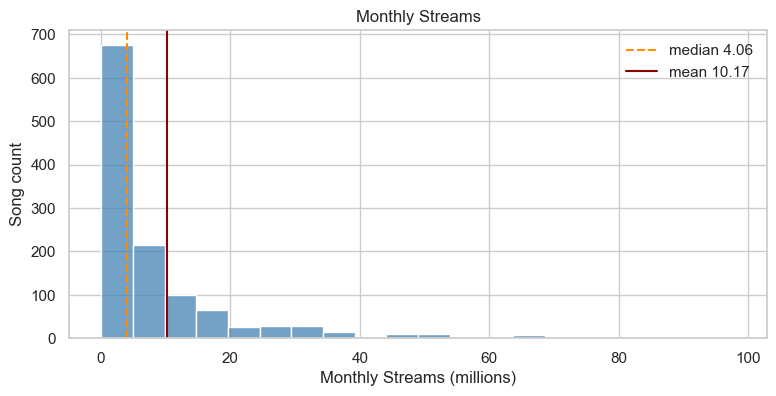

In [173]:
fig, ax= plt.subplots(figsize=(9,4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions <100], x="streams_millions", bins=20, ax=ax, color="steelblue")
ax.axvline(median, color="darkorange", linestyle="--", label=f"median {median:.2f}")
ax.axvline(mean, color="darkred", label=f"mean {mean:.2f}")
ax.legend(frameon=False)
ax.set_xlabel("Monthly Streams (millions)")
ax.set_ylabel("Song count")
ax.set_title("Monthly Streams")
plt.show()

### Monthly listeners

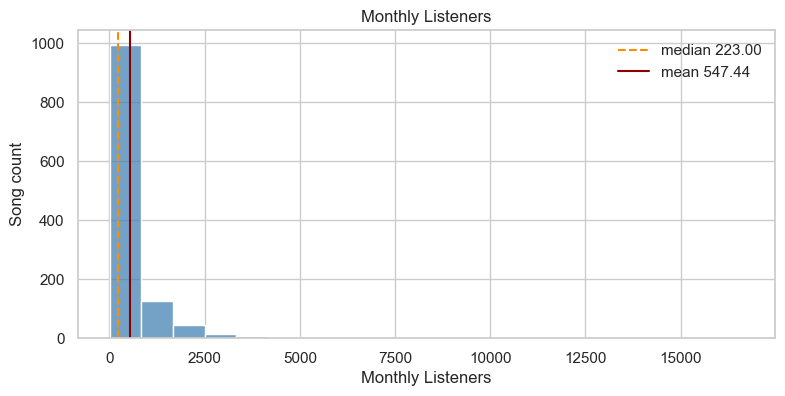

In [174]:
fig, ax= plt.subplots(figsize=(9,4))
median = df.monthly_listeners.median()
mean = df.monthly_listeners.mean()
sns.histplot(data=df, x="monthly_listeners", bins=20, ax=ax, color="steelblue")
ax.axvline(median, color="darkorange", linestyle="--", label=f"median {median:.2f}")
ax.axvline(mean, color="darkred", label=f"mean {mean:.2f}")
ax.legend(frameon=False)
ax.set_xlabel("Monthly Listeners")
ax.set_ylabel("Song count")
ax.set_title("Monthly Listeners")
plt.show()

## Boxplots

In [175]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='str', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

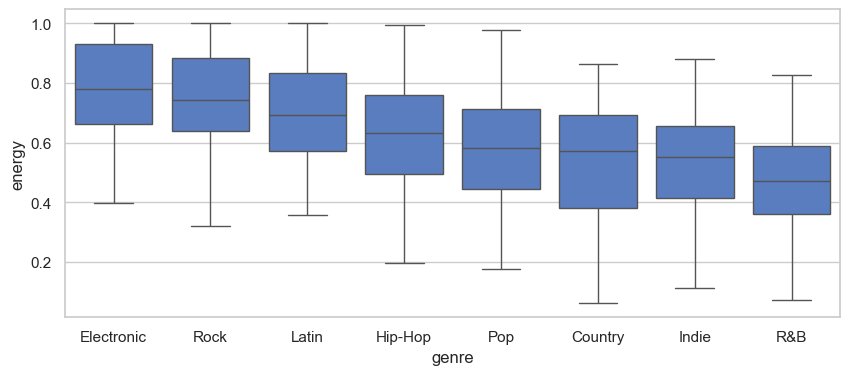

In [176]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, y="energy", x="genre", order=order, ax=ax)

In [177]:
df["monthly_listeners_log"] = np.log(df["monthly_listeners"])
df["monthly_listeners_log"]

0       5.170484
1       5.135798
2       6.646391
3       0.000000
4       0.000000
          ...   
1195    6.100319
1196    7.375882
1197    5.192957
1198    5.733341
1199    6.066108
Name: monthly_listeners_log, Length: 1200, dtype: float64

<Axes: xlabel='genre', ylabel='monthly_listeners'>

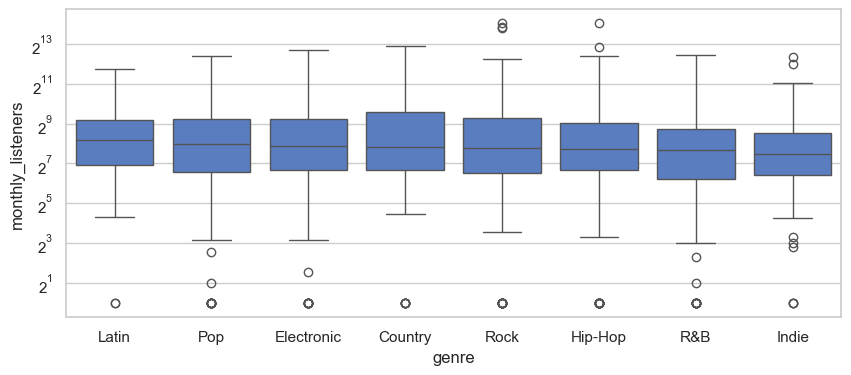

In [178]:
order = df.groupby("genre")["monthly_listeners"].median().sort_values(ascending=False).index
order
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_yscale("log", base=2)
sns.boxplot(data=df, y="monthly_listeners", x="genre", order=order, ax=ax)

In [179]:
len(df["label"].unique())

13

In [180]:
order_l = df.groupby("label")["energy"].median().sort_values(ascending=False).index
order_l

Index(['Secretly Canadian', 'Sony Music', 'Beggars Group', 'Universal Music',
       'Dead Oceans', 'Warner Music', 'Jagjaguwar', 'Interscope', 'Sub Pop',
       'AWAL', 'Concord', 'Big Machine', 'A24 Sounds'],
      dtype='str', name='label')

<Axes: xlabel='label', ylabel='energy'>

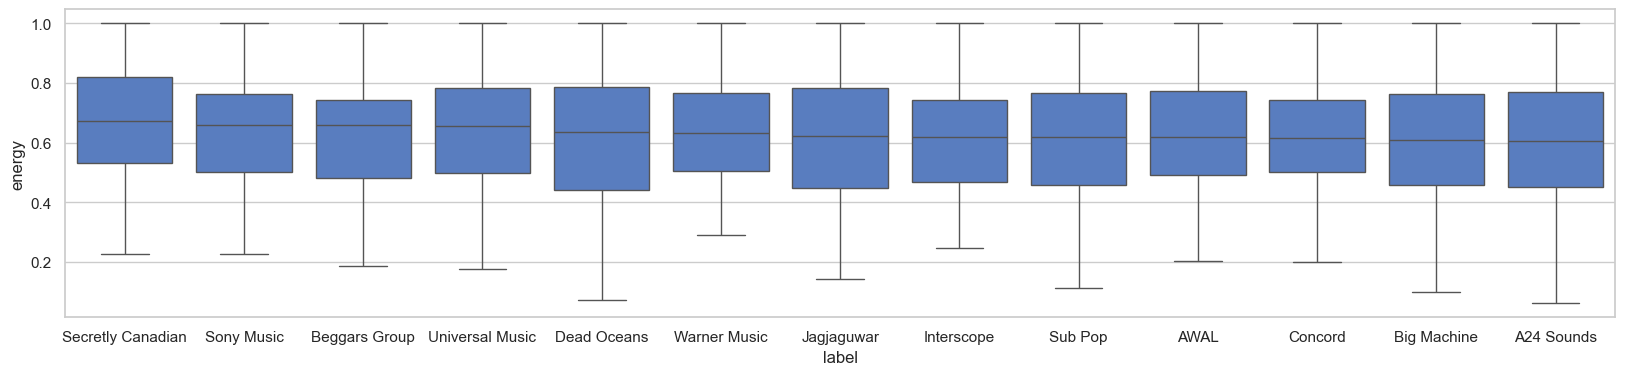

In [181]:
fig, ax = plt.subplots(figsize=(20, 4))
sns.boxplot(data=df, y="energy", x="label", order=order_l, ax=ax)

## Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

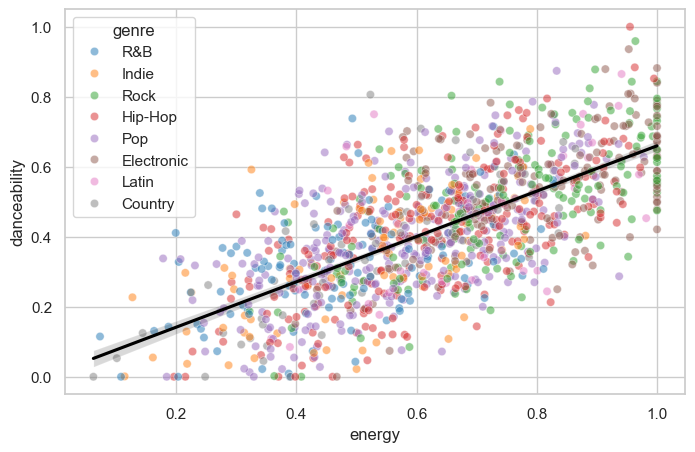

In [182]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", color="grey", alpha=0.5, palette="tab10")
sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="black")

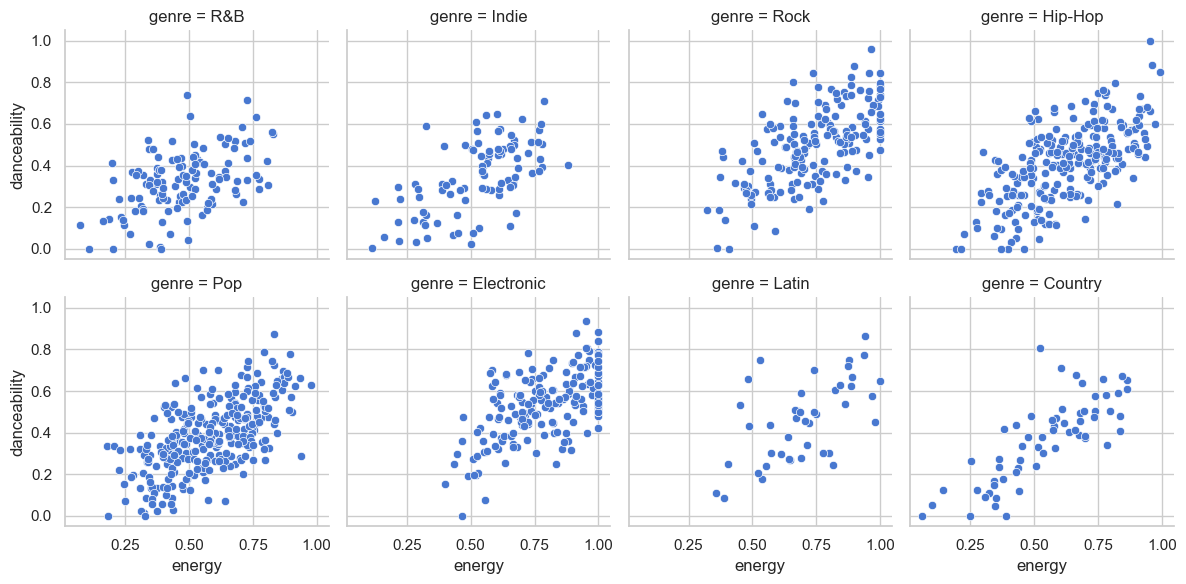

In [183]:
g= sns.FacetGrid(df,col="genre",col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

<Axes: xlabel='acousticness', ylabel='loudness_db'>

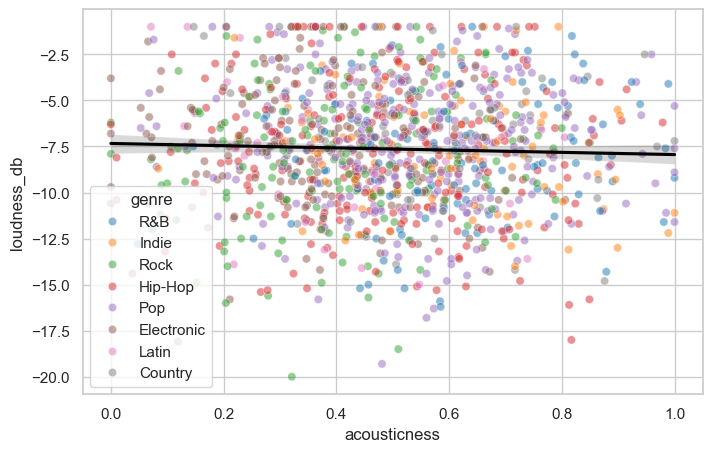

In [184]:
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x="acousticness", y="loudness_db", hue="genre", color="grey", alpha=0.5, palette="tab10")
sns.regplot(data=df, x="acousticness", y="loudness_db", scatter=False, color="black")

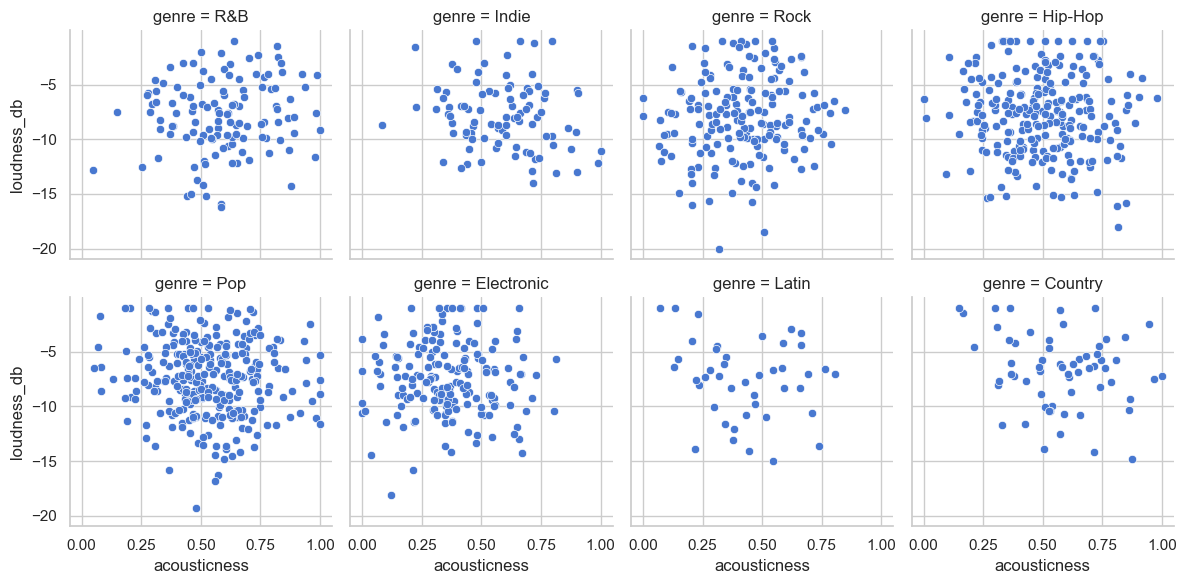

In [185]:
g= sns.FacetGrid(df,col="genre",col_wrap=4)
g.map(sns.scatterplot, "acousticness", "loudness_db")

## Line Charts and Friends

In [186]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label,monthly_listeners_log
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL,5.170484
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds,5.135798
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans,6.646391
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music,0.000000
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds,0.000000


In [187]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [188]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

In [189]:
df.genre.unique()

<StringArray>
['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin', 'Country']
Length: 8, dtype: str

In [190]:
[i for i in zip(axes,genres)]

[(<Axes: title={'center': 'Pop'}>, 'Pop'),
 (<Axes: title={'center': 'Hip-Hop'}>, 'Hip-Hop'),
 (<Axes: title={'center': 'Rock'}>, 'Rock'),
 (<Axes: title={'center': 'Electronic'}>, 'Electronic'),
 (<Axes: title={'center': 'R&B'}>, 'R&B'),
 (<Axes: title={'center': 'Indie'}>, 'Indie')]

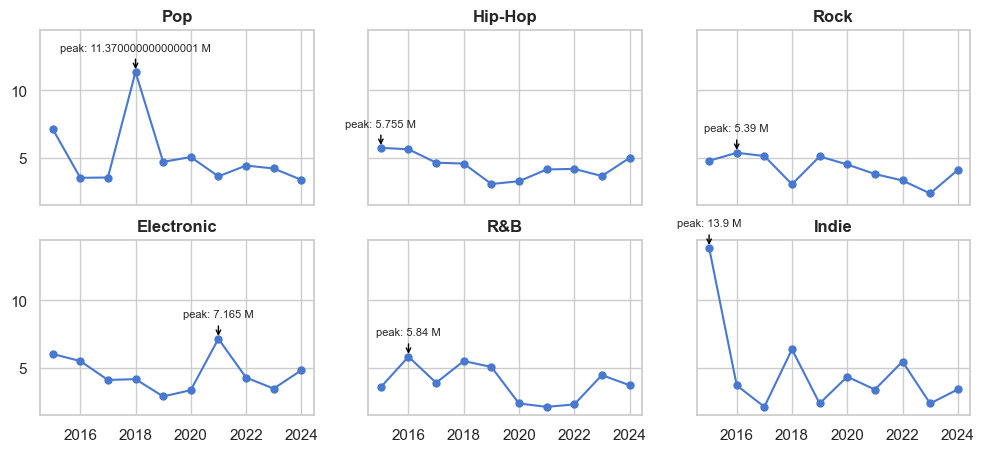

In [191]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2,3,figsize=(12,5),sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions,marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(
        f"peak: {peak.streams_millions} M",
        xy=(peak.year,
        peak.streams_millions),
        xytext=(0,15),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="black", lw=1)
    )
    ax.set_title(genre, fontweight="bold")

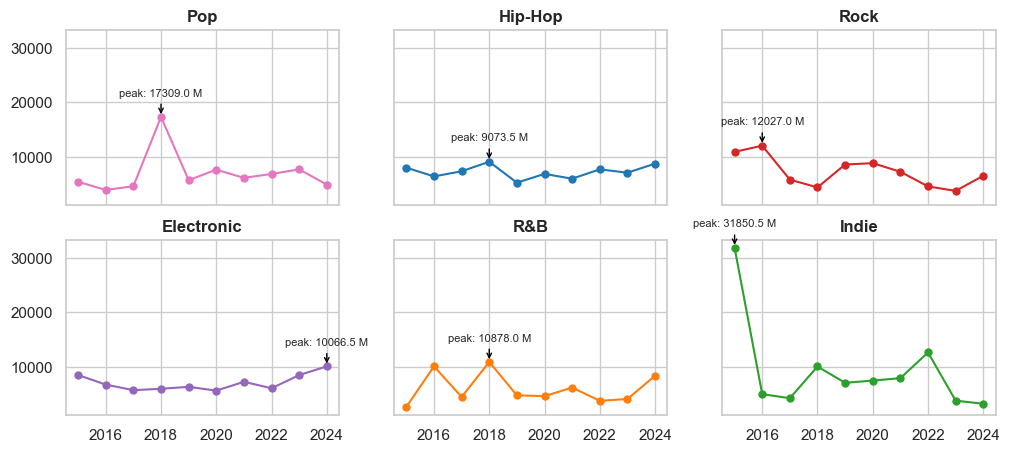

In [192]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["playlist_adds"].median().reset_index()

fig, axes = plt.subplots(2,3,figsize=(12,5),sharex=True, sharey=True)
axes = axes.flatten()
colors = ["tab:pink", "tab:blue", "tab:red", "tab:purple", "tab:orange", "tab:green"]

for ax, genre, col in zip(axes, genres, colors):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.playlist_adds,marker="o", ms=5, color=col)
    peak = subD.loc[subD.playlist_adds.idxmax()]
    ax.annotate(
        f"peak: {peak.playlist_adds} M",
        xy=(peak.year,
        peak.playlist_adds),
        xytext=(0,15),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="black", lw=1)
    )
    ax.set_title(genre, fontweight="bold")

## Altair Vsiualization

In [196]:
df.key.unique()

<StringArray>
[ 'F Minor', 'F# Major',  'D Major',  'A Major', 'G# Major', 'F# Minor',
  'B Minor',  'B Major',  'A Minor',  'E Major',  'C Minor', 'A# Major',
  'D Minor', 'G# Minor',  'F Major', 'D# Major',  'E Minor',  'G Major',
 'D# Minor',  'G Minor', 'C# Minor',  'C Major', 'C# Major', 'A# Minor']
Length: 24, dtype: str

In [235]:
alt.Chart(df).mark_bar().encode(
    alt.X("key:N", title="Key", sort="-y"),
    alt.Y("count()", title="Song count"),
    alt.Color(
        "key:N", 
        scale=alt.Scale(scheme="greenblue"), 
        legend=None
    )
).properties(
    width=1000,
    height=300,
    title="Key Distribution"
)

alt.Chart(...)